In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = "data/customer_churn_1M.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()

Shape: (1000000, 32)


,customer_id,signup_date,age,gender,annual_income,education,marital_status,dependents,tenure,contract,...,has_streaming_tv,has_streaming_movies,customer_satisfaction,num_complaints,num_service_calls,late_payments,avg_monthly_gb,days_since_last_interaction,credit_score,churn
0,CUST0000000001,2022-12-12 12:53:58.199463,43,Female,55085.25,college,married,1,2,two_year,...,1,1,9.0,0.0,0,0,109.63,16,NaN,0
1,CUST0000000002,2022-01-13 12:53:58.199973,18,Male,60786.11,master,married,1,22,one_year,...,0,1,7.0,0.0,3,1,63.25,134,585.0,0
2,CUST0000000003,2023-09-04 12:53:58.199985,38,Female,73184.32,high_school,widowed,0,3,two_year,...,1,0,6.0,1.0,1,0,47.77,11,632.0,0
3,CUST0000000004,2022-06-27 12:53:58.199992,44,Male,40923.78,high_school,married,1,6,two_year,...,0,1,5.0,2.0,2,1,50.82,6,569.0,0
4,CUST0000000005,2022-12-08 12:53:58.199999,45,Female,36400.94,bachelor,single,0,9,two_year,...,0,1,8.0,1.0,1,0,16.74,18,657.0,0


In [41]:
df.info()
df.describe(include="all").T

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 32 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   customer_id                  1000000 non-null  str    
 1   signup_date                  1000000 non-null  str    
 2   age                          1000000 non-null  int64  
 3   gender                       1000000 non-null  str    
 4   annual_income                970041 non-null   float64
 5   education                    1000000 non-null  str    
 6   marital_status               1000000 non-null  str    
 7   dependents                   1000000 non-null  int64  
 8   tenure                       1000000 non-null  int64  
 9   contract                     1000000 non-null  str    
 10  payment_method               1000000 non-null  str    
 11  paperless_billing            1000000 non-null  str    
 12  senior_citizen               1000000 non-null  int64  

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,1000000,1000000,CUST0000000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
signup_date,1000000,1000000,2022-12-12 12:53:58.199463,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,1000000.0,NaN,NaN,NaN,44.724603,14.479468,18.0,34.0,44.0,55.0,90.0
gender,1000000,3,Male,490166,NaN,NaN,NaN,NaN,NaN,NaN,NaN
annual_income,970041.0,NaN,NaN,NaN,58788.311936,37137.433079,20000.0,32712.56,48954.6,73475.13,250000.0
education,1000000,5,bachelor,300324,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital_status,1000000,4,married,450115,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dependents,1000000.0,NaN,NaN,NaN,0.799831,0.893654,0.0,0.0,1.0,1.0,5.0
tenure,1000000.0,NaN,NaN,NaN,22.381923,20.073341,1.0,6.0,16.0,33.0,72.0
contract,1000000,3,one_year,550468,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [42]:
missing = df.isnull().sum().sort_values(ascending=False)

missing[missing > 0]

avg_monthly_gb           50012
credit_score             40395
annual_income            29959
num_complaints           29906
customer_satisfaction    19921
dtype: int64

In [43]:
df["churn"].value_counts()


churn
0    900773
1     99227
Name: count, dtype: int64

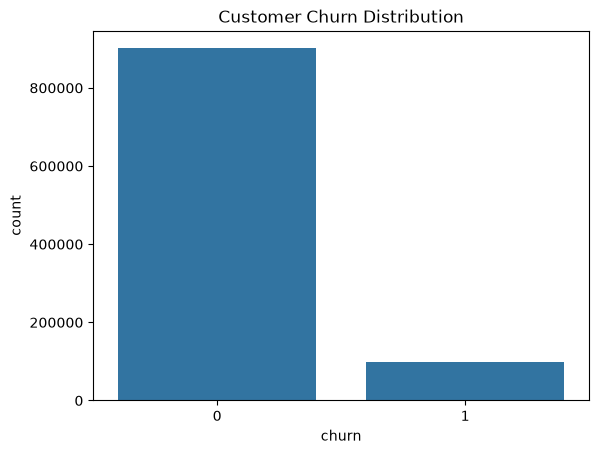

In [44]:
sns.countplot(data=df, x="churn")
plt.title("Customer Churn Distribution")
plt.show()

In [45]:
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical:")
print(categorical_cols)

print("\nNumerical:")
print(numerical_cols)

Categorical:
['customer_id', 'signup_date', 'gender', 'education', 'marital_status', 'contract', 'payment_method', 'paperless_billing']

Numerical:
['age', 'annual_income', 'dependents', 'tenure', 'senior_citizen', 'monthlycharges', 'totalcharges', 'num_services', 'has_phone_service', 'has_internet_service', 'has_online_security', 'has_online_backup', 'has_device_protection', 'has_tech_support', 'has_streaming_tv', 'has_streaming_movies', 'customer_satisfaction', 'num_complaints', 'num_service_calls', 'late_payments', 'avg_monthly_gb', 'days_since_last_interaction', 'credit_score', 'churn']


/tmp/ipykernel_6603/3296647467.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()


In [46]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate customer IDs:", df["customer_id"].duplicated().sum())

Duplicate rows: 0
Duplicate customer IDs: 0


In [47]:
df.dropna(inplace=True)

print("Shape after dropping null values:", df.shape)
df.drop_duplicates(inplace=True)
print("Shape after dropping duplicates:", df.shape)
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]


Shape after dropping null values: (840765, 32)
Shape after dropping duplicates: (840765, 32)


Series([], dtype: int64)

In [48]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler

# Work on a copy so the raw dataframe remains available for reference.
clean_df = df.copy()

# Remove the identifier and exclude records with an unsupported gender category.
clean_df = clean_df.drop(columns=["customer_id"], errors="ignore")
clean_df = clean_df[
    clean_df["gender"].astype("string").str.strip().str.lower().ne("other")
].copy()

# Normalize the target representation and remove invalid target rows.
clean_df["churn"] = clean_df["churn"].astype(str).str.strip().str.lower()
valid_targets = {"0", "1", "true", "false", "yes", "no"}
clean_df = clean_df[clean_df["churn"].isin(valid_targets)].copy()
clean_df["churn"] = clean_df["churn"].map({"true": 1, "yes": 1, "1": 1, "false": 0, "no": 0, "0": 0}).astype(int)

# Remove duplicate records before splitting the data.
clean_df = clean_df.drop_duplicates().reset_index(drop=True)

X = clean_df.drop(columns="churn")
y = clean_df["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

categorical_features = X_train.select_dtypes(include=["object", "string"]).columns.tolist()
numerical_features = X_train.select_dtypes(exclude=["object", "string"]).columns.tolist()

# Avoid huge one-hot matrices: frequency-encode categories with many unique values.
frequency_features = [
    column for column in categorical_features if X_train[column].nunique(dropna=False) > 100
]
one_hot_features = [
    column for column in categorical_features if column not in frequency_features
]

for column in frequency_features:
    frequencies = X_train[column].value_counts(dropna=False, normalize=True)
    X_train[column] = X_train[column].map(frequencies).fillna(0)
    X_test[column] = X_test[column].map(frequencies).fillna(0)

numerical_features = numerical_features + frequency_features

# Fit imputers and encoders on training data only to prevent data leakage.
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            numerical_features,
        ),
        (
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
            ]),
            one_hot_features,
        ),
    ],
    remainder="drop",
)

X_train_standardized = preprocessor.fit_transform(X_train)
X_test_standardized = preprocessor.transform(X_test)

# Normalization rescales every transformed feature to the [0, 1] range.
normalizer = MinMaxScaler()
X_train_normalized = normalizer.fit_transform(X_train_standardized)
X_test_normalized = normalizer.transform(X_test_standardized)

feature_names = preprocessor.get_feature_names_out()
X_train_standardized = pd.DataFrame(
    X_train_standardized, columns=feature_names, index=X_train.index
)
X_test_standardized = pd.DataFrame(
    X_test_standardized, columns=feature_names, index=X_test.index
)
X_train_normalized = pd.DataFrame(
    X_train_normalized, columns=feature_names, index=X_train.index
)
X_test_normalized = pd.DataFrame(
    X_test_normalized, columns=feature_names, index=X_test.index
)

# Public outputs: normalized features and encoded target labels.
X_train = X_train_normalized
X_test = X_test_normalized
Y_train = y_train
Y_test = y_test

print("Clean data shape:", clean_df.shape)
print("Frequency-encoded columns:", frequency_features)
print("One-hot encoded columns:", one_hot_features)
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)
print("Missing values after preprocessing:", X_train.isna().sum().sum())
print("Normalized feature range:", (X_train.min().min(), X_train.max().max()))
X_train.head()

Clean data shape: (823786, 31)
Frequency-encoded columns: ['signup_date']
One-hot encoded columns: ['gender', 'education', 'marital_status', 'contract', 'payment_method', 'paperless_billing']
Training shape: (659028, 44)
Testing shape: (164758, 44)
Missing values after preprocessing: 0
Normalized feature range: (np.float64(0.0), np.float64(1.0000000000000002))


,numerical__age,numerical__annual_income,numerical__dependents,numerical__tenure,numerical__senior_citizen,numerical__monthlycharges,numerical__totalcharges,numerical__num_services,numerical__has_phone_service,numerical__has_internet_service,...,categorical__marital_status_widowed,categorical__contract_month_to_month,categorical__contract_one_year,categorical__contract_two_year,categorical__payment_method_bank_transfer,categorical__payment_method_credit_card,categorical__payment_method_electronic_check,categorical__payment_method_mailed_check,categorical__paperless_billing_No,categorical__paperless_billing_Yes
642251,0.375000,0.040517,0.4,0.112676,0.0,0.104017,0.035194,1.0,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
283263,0.194444,0.161713,0.0,0.112676,0.0,0.078016,0.045773,0.4,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
386827,0.236111,0.124807,0.0,0.154930,0.0,0.079513,0.040249,0.0,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
594508,0.763889,0.420711,0.2,0.366197,0.0,0.052338,0.114530,0.0,1.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
40672,0.513889,0.015431,0.0,0.140845,0.0,0.081633,0.057513,0.6,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [49]:
# Final quality checks for the four public output variables.
assert clean_df.duplicated().sum() == 0
assert clean_df["gender"].astype("string").str.strip().str.lower().ne("other").all()
assert X_train.isna().sum().sum() == 0
assert X_test.isna().sum().sum() == 0
assert X_train.min().min() >= 0
assert X_train.max().max() <= 1 + 1e-12
assert len(X_train) == len(Y_train)
assert len(X_test) == len(Y_test)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Y_train:", Y_train.shape)
print("Y_test:", Y_test.shape)
print("All preprocessing checks passed.")

X_train: (659028, 44)
X_test: (164758, 44)
Y_train: (659028,)
Y_test: (164758,)
All preprocessing checks passed.


In [53]:
# Save the prepared datasets for use in other notebooks.
np.savez_compressed(
    "data/processed_datasets.npz",
    X_train=X_train.to_numpy(dtype="float32"),
    X_test=X_test.to_numpy(dtype="float32"),
    Y_train=Y_train.to_numpy(dtype="int8"),
    Y_test=Y_test.to_numpy(dtype="int8"),
)
print("Saved processed datasets to data/processed_datasets.npz")

Saved processed datasets to data/processed_datasets.npz


,count,mean,std,min,25%,50%,75%,max
numerical__age,659028.0,0.371053,0.201085,0.0,0.222222,0.361111,0.513889,1.0
numerical__annual_income,659028.0,0.168761,0.161452,0.0,0.055261,0.126079,0.232804,1.0
numerical__dependents,659028.0,0.159932,0.178720,0.0,0.000000,0.200000,0.200000,1.0
numerical__tenure,659028.0,0.301049,0.282736,0.0,0.070423,0.211268,0.450704,1.0
numerical__senior_citizen,659028.0,0.198973,0.399228,0.0,0.000000,0.000000,0.000000,1.0
numerical__monthlycharges,659028.0,0.079554,0.032991,0.0,0.060482,0.078387,0.096592,1.0
numerical__totalcharges,659028.0,0.112101,0.111056,0.0,0.028830,0.075888,0.160128,1.0
numerical__num_services,659028.0,0.312607,0.282347,0.0,0.000000,0.200000,0.400000,1.0
numerical__has_phone_service,659028.0,0.769565,0.421111,0.0,1.000000,1.000000,1.000000,1.0
numerical__has_internet_service,659028.0,0.849615,0.357449,0.0,1.000000,1.000000,1.000000,1.0
